# Feature Engineering - Ames Housing Dataset

## Context
This notebook is the second step in the modeling pipeline for the
[Ames Housing dataset](https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques),
a Kaggle regression competition where the goal is to predict residential property
sale prices (`SalePrice`) based on 79 explanatory variables.

All decisions in this notebook are directly grounded in findings from `01_EDA.ipynb`.
The EDA identified three categories of actionable insights: data quality issues
(missing values, outliers), structural patterns (skewed distributions, multicollinearity),
and domain signals (quality orderings, temporal effects) - each of which drives a
specific transformation applied here.

The output of this notebook is a clean, model-ready dataset exported to
`data/processed/train_features.csv` and `data/processed/test_features.csv`.

## Objectives
- Remove the two outliers identified in EDA (`GrLivArea > 4,000 sq ft` with `SalePrice < $300k`)
- Impute missing values using strategies defined per feature type (semantic NaN vs. true missing)
- Apply `log1p` transformation to `SalePrice` and right-skewed numerical features
- Engineer new features that capture relationships the raw variables cannot express directly
- Encode categorical variables using ordinal or one-hot strategies determined by EDA
- Eliminate redundant features identified through multicollinearity analysis
- Export a clean, model-ready dataset for `03_Modeling.ipynb`

## Table of Contents
1. [Imports & Data Loading](#1-imports-data-loading)
2. [Outlier Removal](#2-outlier-removal)
3. [Missing Value Imputation](#3-missing-value-imputation)
   - 3.1 [Semantic NaN - Categorical Features](#31-semantic-nan-categorical)
   - 3.2 [Semantic NaN - Numerical Features](#32-semantic-nan-numerical)
   - 3.3 [True Missing - Targeted Imputation](#33-true-missing)
   - 3.4 [Global Verification](#34-global-verification)
4. [Target Transformation - log1p(SalePrice)](#4-target-transformation)
5. [Feature Creation](#5-feature-creation)
6. [Categorical Encoding](#6-categorical-encoding)
   - 6.1 [Ordinal Encoding - Quality Features](#61-ordinal-encoding)
   - 6.2 [One-Hot Encoding - Structural Features](#62-one-hot-encoding)
7. [Skewness Correction - Numerical Features](#7-skewness-correction)
8. [Feature Selection - Dropping Redundant Variables](#8-feature-selection)
9. [Final Dataset Overview](#9-final-dataset-overview)
10. [Export](#10-export)

## 1. Imports & Data Loading <a id="1-imports-data-loading"></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Display settings
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", "{:.4f}".format)

plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

In [2]:
train_raw = pd.read_csv("../data/raw/train.csv")
test_raw = pd.read_csv("../data/raw/test.csv")

# Store target and ID before any transformation
target = train_raw["SalePrice"].copy()
test_ids = test_raw["Id"].copy()

# Drop target and Id from both sets before concatenation
train_raw = train_raw.drop(columns=["SalePrice", "Id"])
test_raw = test_raw.drop(columns=["Id"])

# Concatenate for unified transformation
df = pd.concat(
    [train_raw, test_raw],
    axis=0,
    ignore_index=True
)

n_train = len(train_raw)

print(f"Train shape : {train_raw.shape}")
print(f"Test shape : {test_raw.shape}")
print(f"Combined df : {df.shape}")
print(f"n_train : {n_train}")

Train shape : (1460, 79)
Test shape : (1459, 79)
Combined df : (2919, 79)
n_train : 1460


In [3]:
df.head()

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,60,RL,65.0000,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0000,Gd,TA,PConc,Gd,TA,No,GLQ,706.0000,Unf,0.0000,150.0000,856.0000,GasA,Ex,Y,SBrkr,856,854,0,1710,1.0000,0.0000,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0000,RFn,2.0000,548.0000,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal
1,20,RL,80.0000,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0000,TA,TA,CBlock,Gd,TA,Gd,ALQ,978.0000,Unf,0.0000,284.0000,1262.0000,GasA,Ex,Y,SBrkr,1262,0,0,1262,0.0000,1.0000,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0000,RFn,2.0000,460.0000,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal
2,60,RL,68.0000,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0000,Gd,TA,PConc,Gd,TA,Mn,GLQ,486.0000,Unf,0.0000,434.0000,920.0000,GasA,Ex,Y,SBrkr,920,866,0,1786,1.0000,0.0000,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0000,RFn,2.0000,608.0000,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal
3,70,RL,60.0000,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0000,TA,TA,BrkTil,TA,Gd,No,ALQ,216.0000,Unf,0.0000,540.0000,756.0000,GasA,Gd,Y,SBrkr,961,756,0,1717,1.0000,0.0000,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0000,Unf,3.0000,642.0000,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml
4,60,RL,84.0000,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0000,Gd,TA,PConc,Gd,TA,Av,GLQ,655.0000,Unf,0.0000,490.0000,1145.0000,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1.0000,0.0000,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0000,RFn,3.0000,836.0000,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal


## 2. Outlier Removal <a id="2-outlier-removal"></a>

Two observations identified in `01_EDA.ipynb` combine a living area above 4,000 sq ft
with a sale price below $300,000, directly contradicting the linear trend established
across all surface features. These are the only observations where removal is clearly
justified. All other flagged points correspond to genuine high-value properties and
are retained.

Removal rule:
- `GrLivArea > 4000` AND `SalePrice < 300,000`

In [4]:
outlier_mask = (train_raw["GrLivArea"] > 4000) & (target < 300_000)
outlier_idx = train_raw[outlier_mask].index

print(f"Outliers identified : {len(outlier_idx)}")
print(f"Indices : {list(outlier_idx)}")
print()
print(train_raw.loc[outlier_idx, ["GrLivArea"]].join(
    target[outlier_idx].rename("SalePrice")
))

Outliers identified : 2
Indices : [523, 1298]

      GrLivArea  SalePrice
523        4676     184750
1298       5642     160000


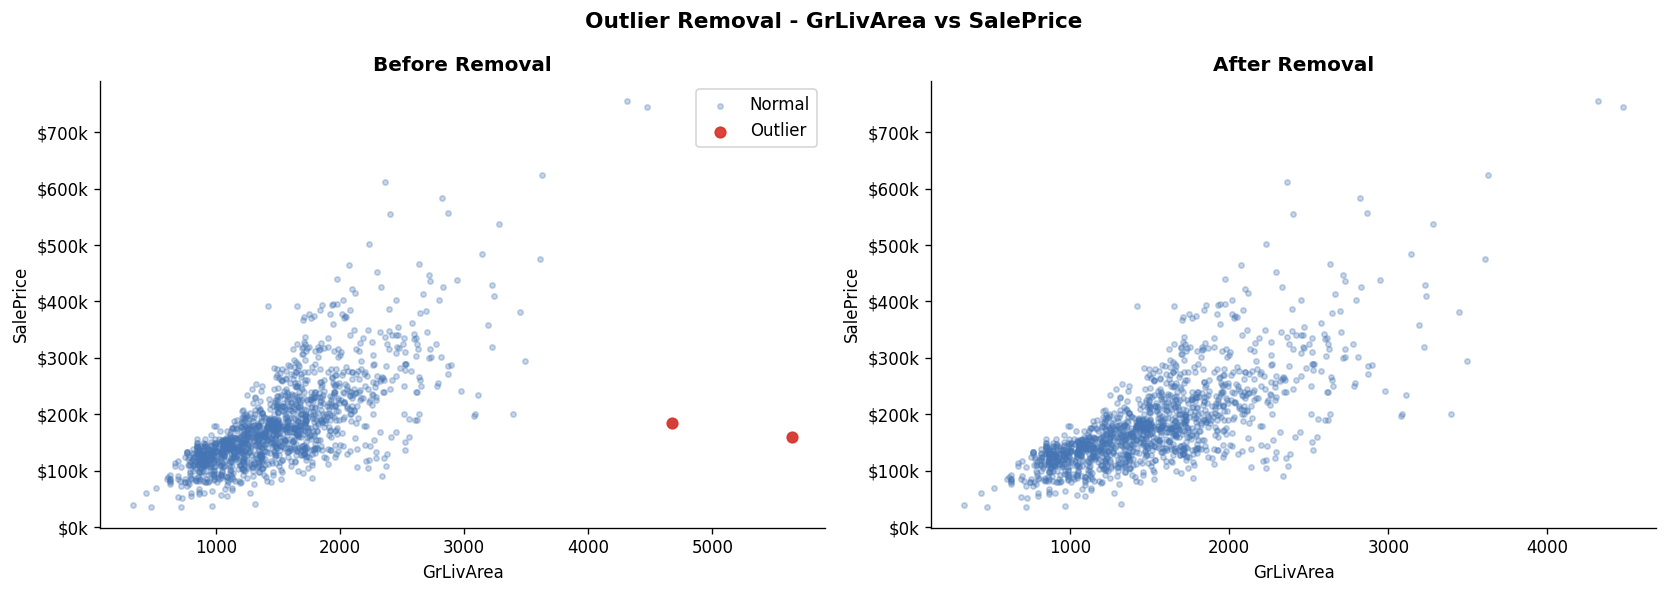

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Before
axes[0].scatter(
    train_raw["GrLivArea"], target,
    alpha=0.3, s=10, color="#4575b4", label="Normal"
)
axes[0].scatter(
    train_raw.loc[outlier_idx, "GrLivArea"],
    target[outlier_idx],
    alpha=0.9, s=40, color="#d73027", zorder=5, label="Outlier"
)
axes[0].set_title("Before Removal", fontsize=12, fontweight="bold")
axes[0].set_xlabel("GrLivArea")
axes[0].set_ylabel("SalePrice")
axes[0].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"${x/1000:.0f}k")
)
axes[0].legend()

# After
clean_mask = ~outlier_mask
axes[1].scatter(
    train_raw.loc[clean_mask, "GrLivArea"],
    target[clean_mask],
    alpha=0.3, s=10, color="#4575b4"
)
axes[1].set_title("After Removal", fontsize=12, fontweight="bold")
axes[1].set_xlabel("GrLivArea")
axes[1].set_ylabel("SalePrice")
axes[1].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"${x/1000:.0f}k")
)

plt.suptitle("Outlier Removal - GrLivArea vs SalePrice",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

In [6]:
df       = df.drop(index=outlier_idx).reset_index(drop=True)
target   = target.drop(index=outlier_idx).reset_index(drop=True)
n_train  = n_train - len(outlier_idx)

print(f"Rows removed        : {len(outlier_idx)}")
print(f"df shape after      : {df.shape}")
print(f"target shape after  : {target.shape}")
print(f"n_train updated     : {n_train}")

Rows removed        : 2
df shape after      : (2917, 79)
target shape after  : (1458,)
n_train updated     : 1458


## 3. Missing Value Imputation <a id="3-missing-value-imputation"></a>

Missing values in this dataset fall into three fundamentally different categories,
each requiring a distinct treatment strategy defined during EDA.

### 3.1 Semantic NaN - Categorical Features <a id="31-semantic-nan-categorical"></a>

These features are missing because the property does not have the corresponding
physical attribute - not because the value is unknown. Each NaN is replaced with
`'None'` to create an explicit category encoding the absence of the feature.

In [7]:
semantic_cat = [
    'PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu',
    'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
    'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
    'MasVnrType',
]

df[semantic_cat] = df[semantic_cat].fillna("None")

print(f"Filled {len(semantic_cat)} categorical features with 'None'")
print(f"Remaining NaN: {df[semantic_cat].isnull().sum().sum()}")

Filled 15 categorical features with 'None'
Remaining NaN: 0


### 3.2 Semantic NaN - Numerical Features <a id="32-semantic-nan-numerical"></a>

These features are the numerical counterparts of the categorical features above.
When a property has no basement, garage, or masonry veneer, the associated areas,
counts, and dimensions should be 0, not missing. Before filling, we verify that
each numerical NaN truly corresponds to an absent attribute (its categorical
counterpart is also NaN/None) rather than a genuine data gap.

In [8]:
bsmt_num = ['BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF',
            'BsmtFullBath', 'BsmtHalfBath']
bsmt_cat = 'BsmtQual'

garage_num = ['GarageArea', 'GarageCars']
garage_cat = 'GarageType'

print("=== Basement numericals ===")
for feat in bsmt_num:
    nan_rows = df[df[feat].isnull()]
    if len(nan_rows) == 0:
        continue
    also_nan = (nan_rows[bsmt_cat] == "None").sum()
    has_bsmt = len(nan_rows) - also_nan
    print(f"  {feat:<15} {len(nan_rows)} NaN | "
          f"{also_nan} semantic (no basement) | {has_bsmt} true missing")

print("\n=== Garage numericals ===")
for feat in garage_num:
    nan_rows = df[df[feat].isnull()]
    if len(nan_rows) == 0:
        continue
    also_nan = (nan_rows[garage_cat] == "None").sum()
    has_garage = len(nan_rows) - also_nan
    print(f"  {feat:<15} {len(nan_rows)} NaN | "
          f"{also_nan} semantic (no garage) | {has_garage} true missing")

print("\n=== MasVnrArea ===")
nan_rows = df[df['MasVnrArea'].isnull()]
also_nan = (nan_rows['MasVnrType'] == "None").sum()
print(f"  MasVnrArea      {len(nan_rows)} NaN | "
      f"{also_nan} semantic (no veneer) | {len(nan_rows) - also_nan} true missing")

=== Basement numericals ===
  BsmtFinSF1      1 NaN | 1 semantic (no basement) | 0 true missing
  BsmtFinSF2      1 NaN | 1 semantic (no basement) | 0 true missing
  BsmtUnfSF       1 NaN | 1 semantic (no basement) | 0 true missing
  TotalBsmtSF     1 NaN | 1 semantic (no basement) | 0 true missing
  BsmtFullBath    2 NaN | 2 semantic (no basement) | 0 true missing
  BsmtHalfBath    2 NaN | 2 semantic (no basement) | 0 true missing

=== Garage numericals ===
  GarageArea      1 NaN | 0 semantic (no garage) | 1 true missing
  GarageCars      1 NaN | 0 semantic (no garage) | 1 true missing

=== MasVnrArea ===
  MasVnrArea      23 NaN | 23 semantic (no veneer) | 0 true missing


In [9]:
#Pure semantic NaN
semantic_num = [
    'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF',
    'BsmtFullBath', 'BsmtHalfBath',
    'MasVnrArea',
]

df[semantic_num] = df[semantic_num].fillna(0)

#GarageArea & GarageCars
for feat in ['GarageArea', 'GarageCars']:
    median_val = df[feat].median()
    n_filled = df[feat].isnull().sum()
    df[feat] = df[feat].fillna(median_val)
    print(f"  {feat}: {n_filled} true missing filled with median = {median_val}")

print(f"\nFilled {len(semantic_num)} features with 0 (semantic)")
print(f"Remaining NaN in numerical semantic+garage: "
      f"{df[semantic_num + ['GarageArea', 'GarageCars']].isnull().sum().sum()}")

  GarageArea: 1 true missing filled with median = 480.0
  GarageCars: 1 true missing filled with median = 2.0

Filled 7 features with 0 (semantic)
Remaining NaN in numerical semantic+garage: 0


### 3.3 True Missing Values <a id="33-true-missing"></a>

The remaining NaN represent genuine data gaps where the value exists but was not
recorded. Each feature is imputed with the most contextually appropriate strategy.

In [10]:
df['LotFrontage'] = df.groupby('Neighborhood')['LotFrontage'].transform(
    lambda x: x.fillna(x.median())
)

df['GarageYrBlt'] = df['GarageYrBlt'].fillna(df['YearBuilt'])

df['Electrical'] = df['Electrical'].fillna(df['Electrical'].mode()[0])

low_freq_cat = ['MSZoning', 'Functional', 'Utilities', 'KitchenQual',
                'Exterior1st', 'Exterior2nd', 'SaleType']

for feat in low_freq_cat:
    mode_val = df[feat].mode()[0]
    n_filled = df[feat].isnull().sum()
    df[feat] = df[feat].fillna(mode_val)
    if n_filled > 0:
        print(f"  {feat}: {n_filled} NaN filled with mode = '{mode_val}'")

print(f"\nLotFrontage NaN remaining: {df['LotFrontage'].isnull().sum()}")
print(f"GarageYrBlt NaN remaining: {df['GarageYrBlt'].isnull().sum()}")
print(f"Electrical  NaN remaining: {df['Electrical'].isnull().sum()}")

  MSZoning: 4 NaN filled with mode = 'RL'
  Functional: 2 NaN filled with mode = 'Typ'
  Utilities: 2 NaN filled with mode = 'AllPub'
  KitchenQual: 1 NaN filled with mode = 'TA'
  Exterior1st: 1 NaN filled with mode = 'VinylSd'
  Exterior2nd: 1 NaN filled with mode = 'VinylSd'
  SaleType: 1 NaN filled with mode = 'WD'

LotFrontage NaN remaining: 0
GarageYrBlt NaN remaining: 0
Electrical  NaN remaining: 0


### 3.4 Global Verification <a id="34-global-verification"></a>

In [11]:
remaining = df.isnull().sum().sum()
print(f"Total remaining NaN in df: {remaining}")

Total remaining NaN in df: 0


## 4. Target Transformation <a id="4-target-transformation"></a>

`SalePrice` follows a right-skewed distribution that violates the normality
assumption of linear models. Applying `log1p` compresses extreme values and
produces a near-Gaussian distribution, which stabilizes both residual variance
and coefficient estimation.

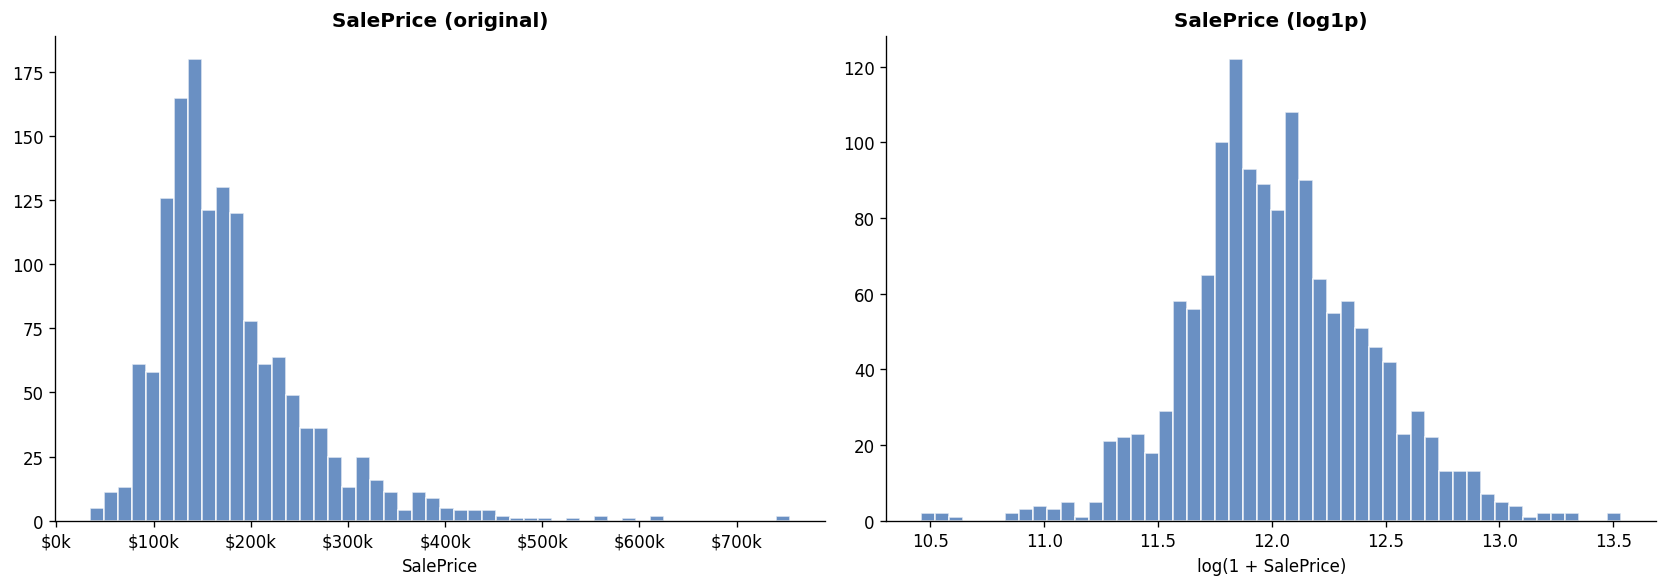

Skewness before: 1.8813
Skewness after:  0.1216


In [12]:
target_log = np.log1p(target)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(target, bins=50, color="#4575b4", edgecolor="white", alpha=0.8)
axes[0].set_title("SalePrice (original)", fontsize=12, fontweight="bold")
axes[0].set_xlabel("SalePrice")
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x/1000:.0f}k"))

axes[1].hist(target_log, bins=50, color="#4575b4", edgecolor="white", alpha=0.8)
axes[1].set_title("SalePrice (log1p)", fontsize=12, fontweight="bold")
axes[1].set_xlabel("log(1 + SalePrice)")

plt.tight_layout()
plt.show()

print(f"Skewness before: {target.skew():.4f}")
print(f"Skewness after:  {target_log.skew():.4f}")

## 5. Feature Creation <a id="5-feature-creation"></a>

New features are derived from existing columns to capture information that raw
variables cannot express individually. Each feature is motivated by domain
knowledge or patterns observed during EDA.

In [13]:
df['TotalSF'] = df['TotalBsmtSF'] + df['1stFlrSF'] + df['2ndFlrSF']
df['TotalBath'] = (df['FullBath'] + df['BsmtFullBath'] + 0.5 * df['HalfBath'] + 0.5 * df['BsmtHalfBath'])
df['TotalPorchSF'] = (df['OpenPorchSF'] + df['EnclosedPorch'] + df['3SsnPorch'] + df['ScreenPorch'])
df['HasRemodel'] = (df['YearRemodAdd'] != df['YearBuilt']).astype(int)
df['HouseAge'] = df['YrSold'] - df['YearBuilt']
df['RemodAge'] = df['YrSold'] - df['YearRemodAdd']

print(f"6 features created | df shape: {df.shape}")
for feat in ['TotalSF', 'TotalBath', 'TotalPorchSF', 'HasRemodel',
             'HouseAge', 'RemodAge']:
    print(f"  {feat:<15} mean={df[feat].mean():.2f}  std={df[feat].std():.2f}")

6 features created | df shape: (2917, 85)
  TotalSF         mean=2542.52  std=781.07
  TotalBath       mean=2.22  std=0.81
  TotalPorchSF    mean=89.07  std=107.71
  HasRemodel      mean=0.47  std=0.50
  HouseAge        mean=36.50  std=30.33
  RemodAge        mean=23.54  std=20.89


## 6. Categorical Encoding <a id="6-categorical-encoding"></a>

### 6.1 Ordinal Encoding <a id="61-ordinal-encoding"></a>

Quality features follow a consistent ordinal scale (Ex > Gd > TA > Fa > Po)
confirmed by monotonic price gradients in EDA. These are mapped to integers
to preserve ranking information. Features with their own distinct scale
(BsmtExposure, BsmtFinType, GarageFinish, Fence) receive dedicated mappings.

In [14]:
quality_map = {'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1, 'None': 0}

ordinal_cols = ['ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond',
                'HeatingQC', 'KitchenQual', 'FireplaceQu',
                'GarageQual', 'GarageCond', 'PoolQC']

for col in ordinal_cols:
    df[col] = df[col].map(quality_map)

bsmt_exposure_map = {'Gd': 4, 'Av': 3, 'Mn': 2, 'No': 1, 'None': 0}
bsmt_fintype_map  = {'GLQ': 6, 'ALQ': 5, 'BLQ': 4, 'Rec': 3,'LwQ': 2, 'Unf': 1, 'None': 0}
garage_finish_map = {'Fin': 3, 'RFn': 2, 'Unf': 1, 'None': 0}
fence_map         = {'GdPrv': 4, 'MnPrv': 3, 'GdWo': 2, 'MnWw': 1, 'None': 0}

df['BsmtExposure'] = df['BsmtExposure'].map(bsmt_exposure_map)
df['BsmtFinType1'] = df['BsmtFinType1'].map(bsmt_fintype_map)
df['BsmtFinType2'] = df['BsmtFinType2'].map(bsmt_fintype_map)
df['GarageFinish'] = df['GarageFinish'].map(garage_finish_map)
df['Fence'] = df['Fence'].map(fence_map)

all_ordinal = ordinal_cols + ['BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'GarageFinish', 'Fence']
print(f"{len(all_ordinal)} features ordinally encoded")
print(f"Unmapped NaN check: {df[all_ordinal].isnull().sum().sum()}")

15 features ordinally encoded
Unmapped NaN check: 0


### 6.2 One-Hot Encoding <a id="62-one-hot-encoding"></a>

All remaining categorical features are nominal (no natural ordering) and are
one-hot encoded. `drop_first=True` removes one dummy per feature to avoid
perfect multicollinearity between encoded columns.

In [15]:
nominal_cols = df.select_dtypes(include=['object', 'string']).columns.tolist()
print(f"{len(nominal_cols)} nominal features to encode:\n{nominal_cols}\n")

df = pd.get_dummies(df, columns=nominal_cols, drop_first=True, dtype=int)

print(f"df shape after encoding: {df.shape}")

28 nominal features to encode:
['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'Foundation', 'Heating', 'CentralAir', 'Electrical', 'Functional', 'GarageType', 'PavedDrive', 'MiscFeature', 'SaleType', 'SaleCondition']

df shape after encoding: (2917, 216)


## 7. Skewness Correction <a id="7-skewness-correction"></a>

Highly skewed numerical features distort coefficient estimation in linear models.
Features exceeding a skewness threshold of 0.75 are transformed with `log1p` to
reduce asymmetry. Only continuous numerical features are considered (ordinal
encoded and binary features are excluded).

In [17]:
all_ordinal = ordinal_cols + ['BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'GarageFinish', 'Fence']

numerical_feats = df.select_dtypes(include=[np.number]).columns.tolist()
exclude = set(all_ordinal + ['HasRemodel'])
continuous = [c for c in numerical_feats
              if c not in exclude and df[c].nunique() > 15]

skewness = df[continuous].skew().sort_values(ascending=False)
high_skew = skewness[skewness.abs() > 0.75]

print(f"{len(high_skew)} features with |skewness| > 0.75")
print(f"out of {len(continuous)} continuous features\n")
print(high_skew.to_string())

19 features with |skewness| > 0.75
out of 26 continuous features

MiscVal         21.9510
LotArea         13.1162
LowQualFinSF    12.0908
3SsnPorch       11.3779
BsmtFinSF2       4.1466
EnclosedPorch    4.0044
ScreenPorch      3.9471
MasVnrArea       2.6231
OpenPorchSF      2.5307
TotalPorchSF     2.2457
WoodDeckSF       1.8457
MSSubClass       1.3758
1stFlrSF         1.2579
LotFrontage      1.1036
GrLivArea        1.0693
TotalSF          1.0097
BsmtFinSF1       0.9811
BsmtUnfSF        0.9202
2ndFlrSF         0.8620


In [18]:
skew_features = high_skew.index.tolist()

skew_before = df[skew_features].skew()
df_transformed = df[skew_features].apply(np.log1p)
skew_after = df_transformed.skew()

improved = skew_after.abs() < skew_before.abs()
apply_cols = improved[improved].index.tolist()
skip_cols  = improved[~improved].index.tolist()

df[apply_cols] = df_transformed[apply_cols]

print(f"Transformed: {len(apply_cols)} features")
print(f"Skipped:     {len(skip_cols)} features (log1p worsened skewness)\n")
print("Skipped features:")
for c in skip_cols:
    print(f"  {c:<18} before={skew_before[c]:.4f}  after={skew_after[c]:.4f}")
print(f"\nTransformed features:")
for c in apply_cols:
    print(f"  {c:<18} before={skew_before[c]:.4f}  after={skew_after[c]:.4f}")

Transformed: 18 features
Skipped:     1 features (log1p worsened skewness)

Skipped features:
  BsmtUnfSF          before=0.9202  after=-2.1553

Transformed features:
  MiscVal            before=21.9510  after=5.2147
  LotArea            before=13.1162  after=-0.5329
  LowQualFinSF       before=12.0908  after=8.5590
  3SsnPorch          before=11.3779  after=8.8267
  BsmtFinSF2         before=4.1466  after=2.4625
  EnclosedPorch      before=4.0044  after=1.9610
  ScreenPorch        before=3.9471  after=2.9461
  MasVnrArea         before=2.6231  after=0.5387
  OpenPorchSF        before=2.5307  after=-0.0416
  TotalPorchSF       before=2.2457  after=-0.5713
  WoodDeckSF         before=1.8457  after=0.1596
  MSSubClass         before=1.3758  after=0.2461
  1stFlrSF           before=1.2579  after=0.0304
  LotFrontage        before=1.1036  after=-1.0690
  GrLivArea          before=1.0693  after=-0.0221
  TotalSF            before=1.0097  after=-0.4297
  BsmtFinSF1         before=0.9811  aft

## 8. Feature Selection <a id="8-feature-selection"></a>

Features are removed based on two criteria established during EDA: redundancy
with composite features created in Section 5, and multicollinearity identified
in the correlation analysis. Each removal is justified by a specific diagnostic
from `01_EDA.ipynb`.

In [19]:
redundancy_checks = [
    ('GarageArea',   'GarageCars',   'EDA: r=0.88, GarageCars more interpretable'),
    ('1stFlrSF',     'TotalSF',      'Absorbed into TotalSF'),
    ('2ndFlrSF',     'TotalSF',      'Absorbed into TotalSF'),
    ('TotalBsmtSF',  'TotalSF',      'Absorbed into TotalSF'),
    ('OpenPorchSF',  'TotalPorchSF', 'Absorbed into TotalPorchSF'),
    ('EnclosedPorch','TotalPorchSF',  'Absorbed into TotalPorchSF'),
    ('3SsnPorch',    'TotalPorchSF',  'Absorbed into TotalPorchSF'),
    ('ScreenPorch',  'TotalPorchSF',  'Absorbed into TotalPorchSF'),
    ('GarageYrBlt',  'HouseAge',      'EDA: r=0.59 with GarageCars, age features preferred'),
    ('YearBuilt',    'HouseAge',      'Absorbed into HouseAge'),
    ('YearRemodAdd', 'RemodAge',      'Absorbed into RemodAge'),
]

print(f"{'Drop':<18} {'Kept':<18} {'Reason'}")
print("=" * 75)
for drop, kept, reason in redundancy_checks:
    if drop in df.columns:
        print(f"  {drop:<16} {kept:<18} {reason}")
    else:
        print(f"  {drop:<16} ** NOT FOUND **")

Drop               Kept               Reason
  GarageArea       GarageCars         EDA: r=0.88, GarageCars more interpretable
  1stFlrSF         TotalSF            Absorbed into TotalSF
  2ndFlrSF         TotalSF            Absorbed into TotalSF
  TotalBsmtSF      TotalSF            Absorbed into TotalSF
  OpenPorchSF      TotalPorchSF       Absorbed into TotalPorchSF
  EnclosedPorch    TotalPorchSF       Absorbed into TotalPorchSF
  3SsnPorch        TotalPorchSF       Absorbed into TotalPorchSF
  ScreenPorch      TotalPorchSF       Absorbed into TotalPorchSF
  GarageYrBlt      HouseAge           EDA: r=0.59 with GarageCars, age features preferred
  YearBuilt        HouseAge           Absorbed into HouseAge
  YearRemodAdd     RemodAge           Absorbed into RemodAge


In [20]:
drop_cols = ['GarageArea', '1stFlrSF', '2ndFlrSF', 'TotalBsmtSF',
             'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch',
             'GarageYrBlt', 'YearBuilt', 'YearRemodAdd']

df = df.drop(columns=drop_cols)

print(f"{len(drop_cols)} features dropped | df shape: {df.shape}")

11 features dropped | df shape: (2917, 205)


## 9. Export <a id="9-export"></a>

The processed DataFrame is split back into train and test sets using the
`n_train` counter maintained since Section 1. All files are saved in
`../data/processed/` for direct use in the modeling notebook.

In [22]:
X_train = df.iloc[:n_train].reset_index(drop=True)
X_test  = df.iloc[n_train:].reset_index(drop=True)

print(f"X_train : {X_train.shape}")
print(f"X_test  : {X_test.shape}")
print(f"target  : {target_log.shape}")
print(f"test_ids: {test_ids.shape}")
print(f"\nNaN check: train={X_train.isnull().sum().sum()}, "
      f"test={X_test.isnull().sum().sum()}")

X_train : (1458, 205)
X_test  : (1459, 205)
target  : (1458,)
test_ids: (1459,)

NaN check: train=0, test=0


In [23]:
import os

output_dir = "../data/processed"
os.makedirs(output_dir, exist_ok=True)

X_train.to_csv(f"{output_dir}/X_train.csv", index=False)
X_test.to_csv(f"{output_dir}/X_test.csv", index=False)
target_log.to_csv(f"{output_dir}/y_train.csv", index=False, header=["SalePrice_log"])
test_ids.to_csv(f"{output_dir}/test_ids.csv", index=False, header=["Id"])

print("Saved to ../data/processed/")
for f in os.listdir(output_dir):
    size = os.path.getsize(f"{output_dir}/{f}") / 1024
    print(f"  {f:<25} {size:.1f} KB")

Saved to ../data/processed/
  test_ids.csv              7.1 KB
  X_train.csv               792.6 KB
  y_train.csv               26.8 KB
  X_test.csv                793.3 KB
